In [1]:
import numpy as np
import matplotlib.pyplot as plt

RuntimeError: module compiled against API version 0xe but this version of numpy is 0xd

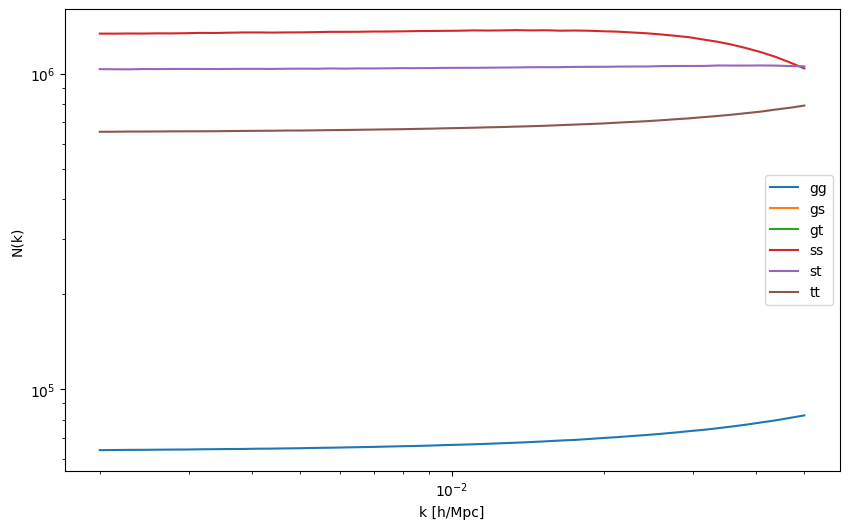

In [2]:
import pandas as pd

# Load results
df = pd.read_pickle('../quadratic_results.pkl')

# Access specific results
k_values = df['K']
gg_means = df['gg_galgal_mean']#**-1.

# Plot results
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
r = {}

for estimator_pair in ['gg', 'gs', 'gt', 'ss', 'st', 'tt']:
    key = f"{estimator_pair}_galgal_mean"
    if key in df:
        plt.loglog(df['K'], df[key]**-1., label=estimator_pair)
        r[estimator_pair] = (df['K'], df[key]**-1.)
plt.legend()
plt.xlabel('k [h/Mpc]')
plt.ylabel('N(k)')
plt.show()

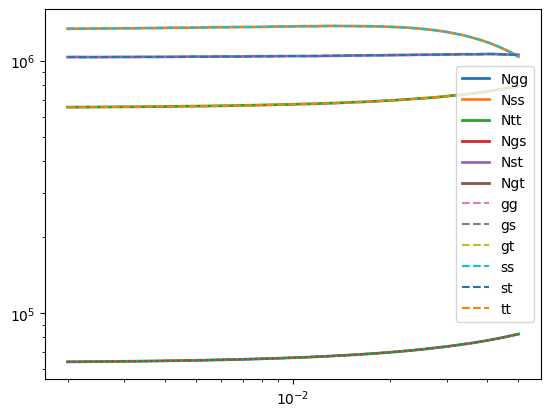

In [3]:
nomi = ["desi", "desiasymm"]
nomi = ["desiasymm"]

kk, nn = np.loadtxt("../output/desiasymm/data_dir/Ngg.txt").T
knew, nnew = np.loadtxt("../Ngg_new.txt").T

for i, nome in enumerate(nomi):
    directory = f"/home/users/d/darwish/quadraticrecforlss/example/output/{nome}/data_dir/"
    Ns = {k: np.loadtxt(directory+f"{k}.txt").T for k in ["Ngg", "Nss", "Ntt", "Ngs", "Nst", "Ngt"]}
    vals = {k: np.loadtxt(directory+f"values{k}.txt").T for k in ["gg", "ss", "tt"]}

    linear_power = np.loadtxt(directory+"linear_power.txt").T
    nonlinear_power = np.loadtxt(directory+"nonlinear_power.txt").T

    for k, v in Ns.items():
        K, N = v
        plt.loglog(K, N, lw = 2, label = k if i == 0 else None, ls = "--" if i > 0 else "-")

power = np.interp(K, linear_power[0], linear_power[1])
#plt.plot(K, power, lw = 2, color = "black", label = "Linear Matter Power Spectrum")


"""for k in vals.keys():
    K, alpha_ab_beta_ab, alpha_ab_beta_ba, alpha_ba_beta_ab, alpha_ba_beta_ba = vals[k]
    X = (alpha_ab_beta_ab+alpha_ab_beta_ba+alpha_ba_beta_ab+alpha_ba_beta_ba)
    plt.loglog(K, X**-1., ls = "--")"""


for k in r.keys():
    plt.loglog(*r[k], ls = "--", label = k)
    
plt.plot(kk, nn**-1)
plt.plot(knew, nnew, ls = ":")


plt.legend()

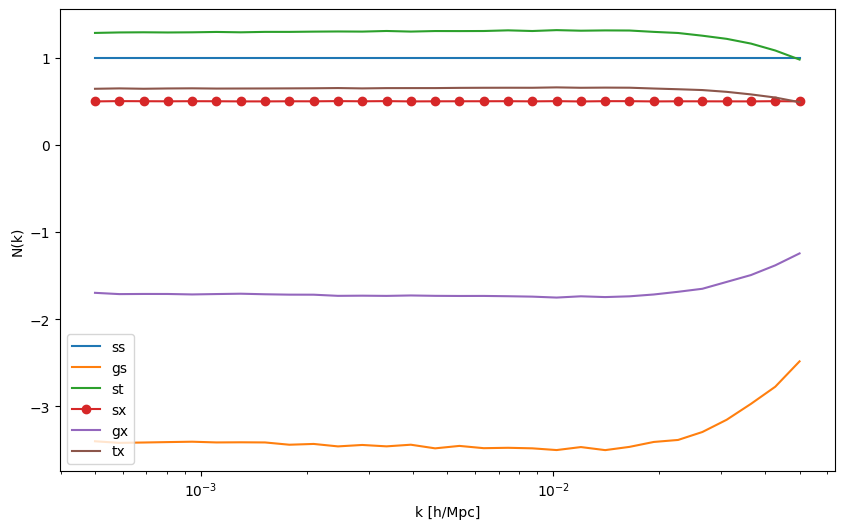

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
df = pd.read_pickle('../output/desiasymm/data_dir/quadratic_results.pkl')
for estimator_pair in ['ss', 'gs', 'st', 'sx', 'gx', 'tx']:
    key = f"{estimator_pair}_galgal"
    if key in df:
        if estimator_pair == "ss":
            Naa = df[key]**-1.
        plt.plot(df['K'], (Naa*df[key]), label=estimator_pair, marker = "o" if 'sx' in estimator_pair else None)
plt.legend()
plt.xlabel('k [h/Mpc]')
plt.ylabel('N(k)')
plt.xscale("log")
plt.show()

In [3]:
Ns.keys()

dict_keys(['Ngg', 'Nss', 'Ntt', 'Ngs', 'Nst', 'Ngt'])

In [48]:
from scipy.interpolate import UnivariateSpline
from scipy.integrate import quad

knl, pnl = nonlinear_power
pnlf = UnivariateSpline(knl, pnl)

kl, pl = linear_power
plf = UnivariateSpline(knl, pl)
plf_loglog = UnivariateSpline(np.log(knl), np.log(pl))
pldf = plf_loglog.derivative(1)

fss = lambda k: k**2*plf(k)**2/pnlf(k)**2*(0.5+1/3*pldf(k))
fsg = lambda k: k**2*plf(k)**2/pnlf(k)**2*(-1-2/3*pldf(k))

factor_ss = quad(fss, 0.051, 0.15)[0]
factor_sg = quad(fsg, 0.051, 0.15)[0]
print(factor_sg/factor_ss, factor_ss/factor_sg)




-2.0 -0.5


In [4]:
D = np.load(directory+f"valuesss.npy", allow_pickle=True).item()

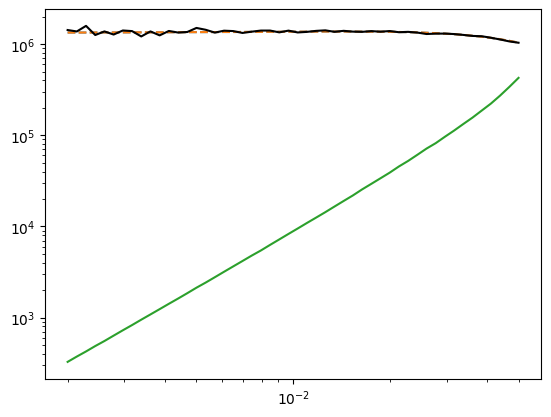

In [5]:
K, alpha_ab_beta_ab, alpha_ab_beta_ba, alpha_ba_beta_ab, alpha_ba_beta_ba = vals["ss"]
X = (alpha_ab_beta_ab+alpha_ab_beta_ba+alpha_ba_beta_ab+alpha_ba_beta_ba)
plt.loglog(K, X**-1., ls = "--")
y = X**-1.
lista = ["alpha_ab_beta_ab", "alpha_ab_beta_ba", "alpha_ba_beta_ab", "alpha_ba_beta_ba"]
s1, s2 = "m", "m"
X = np.sum([D[l+f"_{s1+s2}"] for l in lista], axis = 0)
plt.loglog(K, X**-1., ls = "--")

fmm_1 = D["alpha_ab_beta_ab_mm"]+D["alpha_ab_beta_ab_mm"]
fmm_2 = D["alpha_ab_beta_ba_mm"]+D["alpha_ab_beta_ba_mm"]
b_1 = 1
b_2 = 2
total = b_1*fmm_1+b_2*fmm_2
#total *= 5/3*4e-3
plt.plot(K, -total**-1.)

total_eq = b_1*fmm_1+b_1*fmm_2
#total_eq *= 5/3*4e-3
plt.plot(K, total_eq**-1., color = "black")

In [55]:
Ns[f"Nss"][-1]/Ns["Ngs"][-1], -4*17/21

(array([-3.4272957 , -3.42882763, -3.426308  , -3.4327764 , -3.43601964,
        -3.43832708, -3.44076433, -3.44106189, -3.43974532, -3.44671801,
        -3.45053658, -3.45398608, -3.45366584, -3.45249199, -3.45450569,
        -3.46583823, -3.46269882, -3.46779524, -3.4675699 , -3.48013347,
        -3.47631361, -3.48240527, -3.48092769, -3.48761078, -3.48090902,
        -3.48688614, -3.4832936 , -3.48408699, -3.48247014, -3.47736421,
        -3.48289723, -3.47840348, -3.46263606, -3.45852072, -3.44259026,
        -3.42612564, -3.40195942, -3.38051755, -3.34446194, -3.31101116,
        -3.27244268, -3.20940168, -3.14959204, -3.08114024, -2.98975627,
        -2.9069457 , -2.81910603, -2.71389371, -2.60670764, -2.48430528]),
 -3.238095238095238)

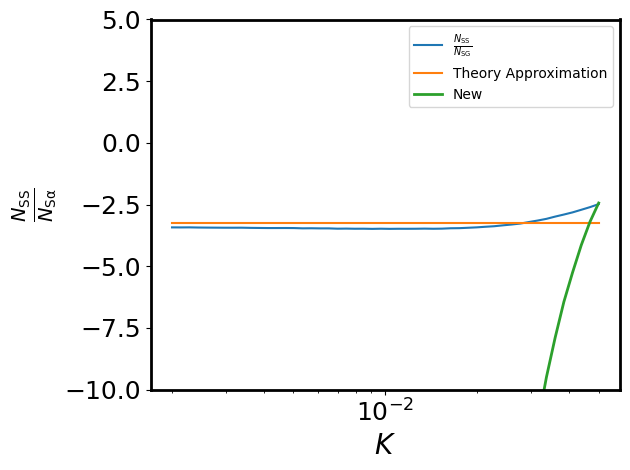

In [43]:
key = "s"
lista = Ns.keys()
lista = ["Ngs"]
somma = np.sum([Ns[f"N{key}{key}"][-1]/Ns[k][-1] for k in lista if key in k], axis = 0)
plt.plot(K, somma, label = r"$\frac{N_{\mathrm{SS}}}{N_{\mathrm{SG}}}$")
plt.plot(K, K*0-4*17/21, label = "Theory Approximation")

plt.plot(K, total*Ns[f"N{key}{key}"][-1], lw = 2, label = "New")

#plt.plot(K, total_eq*Ns[f"N{key}{key}"][-1], lw = 1, label = "New with same biases", color = "black", ls = "--")

#lista = ["Ngt"]
#somma = np.sum([Ns[f"N{key}{key}"][-1]/Ns[k][-1] for k in lista if key in k], axis = 0)
#plt.loglog(K, abs(somma))
plt.tick_params(labelsize = 18)
plt.xscale("log")
plt.xlabel(r"$K$", fontsize = 20)
# Get the current axes
ax = plt.gca()  # gca stands for "get current axes"

# Make the frame (spines) thicker
for spine in ax.spines.values():
    spine.set_linewidth(2.)  # Adjust thickness as needed (2.5 is quite thick)

plt.ylabel(r"$\frac{N_{\mathrm{SS}}}{N_{\mathrm{S\alpha}}}$", fontsize = 20)
plt.ylim(-10, 5)
plt.legend()
plt.tight_layout()
plt.savefig("bias_trend.pdf", dpi = 300)

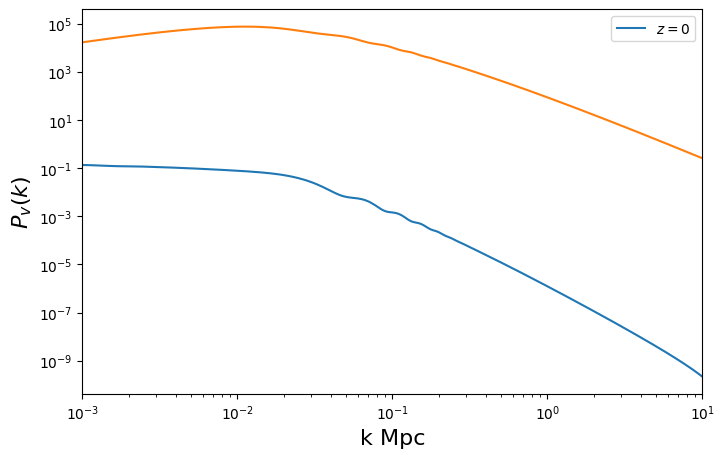

In [15]:
import camb
from camb import model
#from nbodykit.lab import *
#import nbodykit
#cosmo = cosmology.Planck15

kmax=10 
k_per_logint = 30
zs = [0]#, 3, 10, 200, 500,800, 1090]

pars = camb.CAMBparams()
pars.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122)
pars.InitPower.set_params(ns=0.965)
pars.WantTransfer = True
pars.set_matter_power(redshifts=zs, kmax=kmax, k_per_logint=k_per_logint, silent=True)
results = camb.get_results(pars)

PKint = results.get_matter_power_interpolator(nonlinear=False, 
    hubble_units=False, k_hunit=False, 
    var1=model.Transfer_tot, var2=model.Transfer_vel_baryon_cdm)

plt.figure(figsize=(8,5))
ks = np.logspace(-3, np.log10(kmax), 300)
for i, z in enumerate(zs):
     curlyP = PKint.P(z,ks)
     plt.semilogx(ks, curlyP)

PKint = results.get_matter_power_interpolator(nonlinear=False, 
    hubble_units=False, k_hunit=False, 
    var1=model.Transfer_tot, var2=model.Transfer_tot)

for i, z in enumerate(zs):
     curlyP = PKint.P(z,ks)
     plt.semilogx(ks, curlyP)
    
plt.xlim([1e-3,kmax])
plt.xlabel('k Mpc', fontsize=16)
plt.ylabel(r'$P_v(k)$', fontsize=16)
plt.yscale("log")
plt.legend(['$z = %s$'%z for z in zs]);